In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.font_manager as fm
font_path = '/n/home12/mhe/.cache/matplotlib/Helvetica.ttf'
fm.fontManager.addfont(font_path)
matplotlib.rcParams['font.family'] = 'Helvetica'

In [2]:
title_font_path = '/n/home12/mhe/.cache/matplotlib/Helvetica-Bold.ttf'
title_font = fm.FontProperties(fname=title_font_path)

In [3]:
# create a dataframe with columns year, OH contribution, E contribution, relaxation
years = [2019, 2020, 2021, 2022, 2023, 2024]

# df = pd.DataFrame({
#     'year': years,
#     'OH': [0.0, 1.41, 7.77, 9.82, 7.15, 3.53],
#     'emissions': [0.0, 8.6, 30.8, 2.7, 0.7, 4.53],
#     'anthropogenic': [0.0, 13.6, 30, 11.83, 20.9, 23.41],
#     'wetlands': [0.0, -5, 0.78, -9.16, -20.1, -18.9],
#     'relaxation': [27.76, 25.04, 20.67, 16.8, 14.2, 12.56],
#     'growth': [27.76, 35.06, 59.36, 29.56, 22.26, 20.73],
#     'NOAA growth': [9.61, 14.75, 17.68, 13.15, 8.53, 9.52]
# })

# revised 4/30/25 to account for k_total
# df = pd.DataFrame({
#     'year': years,
#     'OH': [0.0, 1.41, 7.77, 9.82, 7.15, 3.53],
#     'emissions': [0.0, 8.6, 30.8, 2.7, 0.7, 4.53],
#     'anthropogenic': [0.0, 13.6, 30, 11.83, 20.9, 23.41],
#     'wetlands': [0.0, -5, 0.78, -9.16, -20.1, -18.9],
#     'relaxation': [27.75, 24.79, 20.03, 15.82, 13, 11.2],
#     'growth': [27.75, 35.01, 59.75, 29.89, 21.63, 18.457],
#     'NOAA growth': [9.61, 14.75, 17.68, 13.15, 8.53, 9.52]
# })

# df['NOAA growth'] = df['NOAA growth'] * 2.77 # Nisbet et al 2023

In [9]:
# should be same as above
years = [2019, 2020, 2021, 2022, 2023, 2024]

df = pd.DataFrame({
    'year': years,
    'emissions': [570.6, 579.2, 601.4, 573.3, 571.3, 575.13], # Tg, without accounting for soil
    # 'emissions': [567.7, 579, 601.5, 575, 571.5, 575.3], # Tg, accounting for soil optimization
    'loss to OH': [467.8, 469.1, 467, 468.7, 474, 479.36], # Tg
    'soil sink': np.repeat([33.554], 6), # Tg, prior soil sink
    'methane mass': [5128.9, 5158.7, 5206.61, 5249, 5277.5, 5295.55], # Tg
    'k_total': [0.099299201, 0.098985258, 0.09758719, 0.097134664, 0.097794776, 0.098784651],
    # 'NOAA growth': [9.62, 14.75, 17.69, 13.12, 8.57, 8.95] # from Lan 2025
    # 'NOAA growth': [9.2, 12.18, 16.09, 16.11, 10.52, 8.14] # from Lan 2025
    'NOAA growth': [9.61, 14.84, 17.69, 12.91, 8.72, 7.29] # from Lan 2025
})

emis_2019 = df['emissions'][0]
m_2019 = df['methane mass'][0]
df['delta_emissions'] = df['emissions'] - emis_2019 # term 2
df['delta_m'] = df['methane mass'] - m_2019
df['k_OH'] = df['loss to OH'] / df['methane mass']
k_OH_2019 = df['k_OH'][0]
df['delta_k_OH'] = df['k_OH'] - k_OH_2019
df['OH contribution'] = -m_2019 * df['delta_k_OH'] # term 3
df['relaxation'] = emis_2019 - df['k_total'][0] * m_2019 - df['soil sink'][0] - df['k_total'][0] * df['delta_m'] # term 1
df['G_j'] = df['relaxation'] + df['delta_emissions'] + df['OH contribution']

df['NOAA growth'] = df['NOAA growth'] * 2.77 # Nisbet et al 2023

In [10]:
df

,year,emissions,loss to OH,soil sink,methane mass,k_total,NOAA growth,delta_emissions,delta_m,k_OH,delta_k_OH,OH contribution,relaxation,G_j
0,2019,570.60,467.80,33.554,5128.90,0.099299,26.6197,0.00,0.00,0.091209,0.000000,-0.000000,27.750328,27.750328
1,2020,579.20,469.10,33.554,5158.70,0.098985,41.1068,8.60,29.80,0.090934,-0.000275,1.409826,24.791212,34.801038
2,2021,601.40,467.00,33.554,5206.61,0.097587,49.0013,30.80,77.71,0.089694,-0.001515,7.770096,20.033787,58.603883
3,2022,573.30,468.70,33.554,5249.00,0.097135,35.7607,2.70,120.10,0.089293,-0.001915,9.824113,15.824494,28.348607
4,2023,571.30,474.00,33.554,5277.50,0.097795,24.1544,0.70,148.60,0.089815,-0.001393,7.146547,12.994467,20.841013
5,2024,575.13,479.36,33.554,5295.55,0.098785,20.1933,4.53,166.65,0.090521,-0.000687,3.525372,11.202116,19.257489


In [6]:
emissions_total = df['delta_emissions'].sum()
OH_total = df['OH contribution'].sum()
relaxation_total = df['relaxation'].sum()

print(f"Total emissions contribution: {emissions_total:.2f} Tg")
print(f"Total OH contribution: {OH_total:.2f} Tg")
print(f"Total relaxation contribution: {relaxation_total:.2f} Tg")
print(f"Emissions contribution: {emissions_total / (emissions_total + OH_total + relaxation_total) * 100:.2f}%")
print(f"OH contribution: {OH_total / (emissions_total + OH_total + relaxation_total) * 100:.2f}%")
print(f"Relaxation contribution: {relaxation_total / (emissions_total + OH_total + relaxation_total) * 100:.2f}%")

Total emissions contribution: 47.33 Tg
Total OH contribution: 29.68 Tg
Total relaxation contribution: 112.60 Tg
Emissions contribution: 24.96%
OH contribution: 15.65%
Relaxation contribution: 59.39%


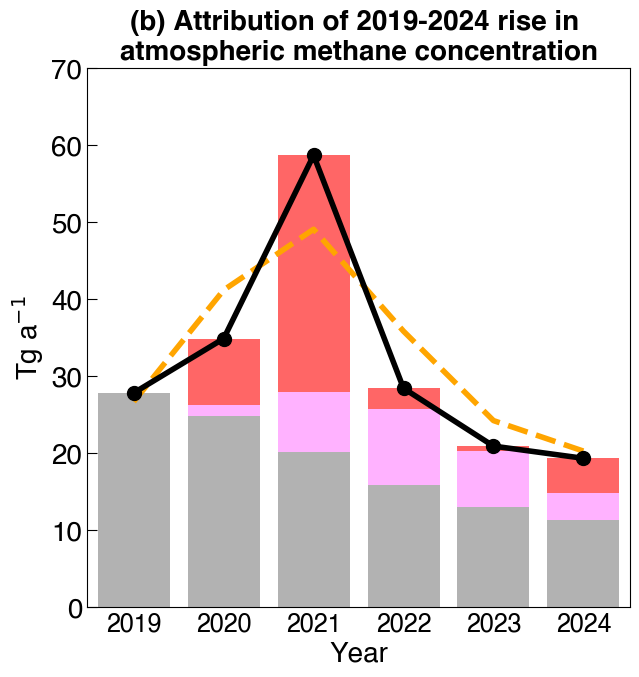

In [24]:
# version 2
fig, ax = plt.subplots(figsize=(7,7))
plt.rcParams.update({'font.size': 20})

ax.bar(df['year'], df['delta_emissions'], color='red', bottom=df['relaxation'] + df['OH contribution'], alpha=0.6, label='ΔEmissions vs. 2019')
ax.bar(df['year'], df['OH contribution'], color='magenta', bottom=df['relaxation'], alpha=0.3, label='ΔOH vs. 2019')
ax.bar(df['year'], df['relaxation'], color='grey', alpha=0.6, label='Relaxation to steady \nstate (2019 conditions)')
ax.plot(df['year'], df['NOAA growth'], color='orange', markersize=10, linestyle='--', lw=4, label='NOAA growth rate')
ax.plot(df['year'], df['G_j'], color='black', marker='o', markersize=10, lw=4, label='Posterior growth rate')

ax.set_ylim(0, 70)
ax.set_xlabel('Year')
ax.tick_params(axis='x', labelsize=18)
ax.margins(x=0.02)
ax.set_ylabel('Tg a$^{-1}$')
ax.tick_params(axis='x', which='both', length=0)
ax.tick_params(axis='y', direction='in', length=7)
ax.set_title('(b) Attribution of 2019-2024 rise in \natmospheric methane concentration', fontproperties=title_font, fontsize=20)
# ax.set_title('$\\mathbf{B}$   ' +
#              'Attribution of 2019–2024 rise in \natmospheric methane concentration',
#              fontsize=20)

# plt.savefig('figures/2b_revised.png', bbox_inches='tight', dpi=1200)
plt.show()

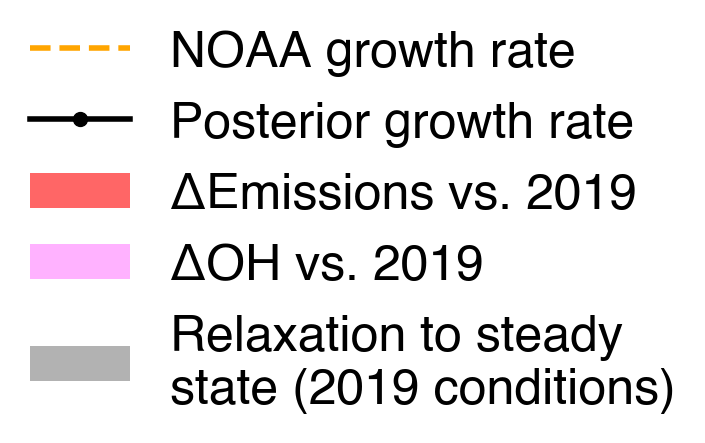

In [21]:
handles, labels = ax.get_legend_handles_labels()

fig_leg = plt.figure(figsize=(4, 2))
fig_leg.legend(handles, labels, loc='center', frameon=False, fontsize=36)
plt.axis('off')

plt.tight_layout()
plt.savefig('figures/2b_legend.png', bbox_inches='tight', dpi=1200)
plt.show()

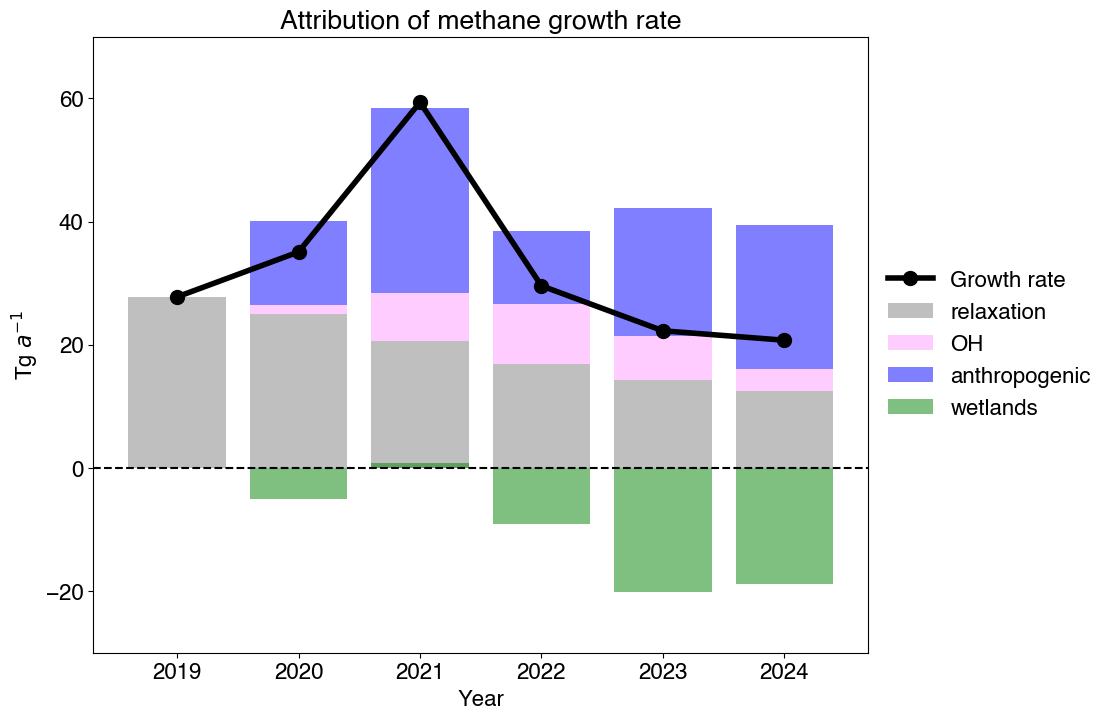

In [ ]:
# plot df as stacked bar chart with year on the x-axis and OH, emissions, relaxation as stacked bars
plt.figure(figsize=(10, 8))
plt.rcParams.update({'font.size': 16})

pos_cols = ['relaxation', 'OH', 'anthropogenic']
neg_cols = ['wetlands']

# plot postiive bars
bottom_pos = np.zeros(len(df))
colors_pos = ['grey', 'magenta', 'blue']
for col, color in zip(pos_cols, colors_pos):
    if color == 'magenta':
        plt.bar(df['year'], df[col], bottom=bottom_pos, color=color, alpha=0.2, label=col)
    else:
        plt.bar(df['year'], df[col], bottom=bottom_pos, color=color, alpha=0.5, label=col)
    bottom_pos += df[col]

# plot negative bars
bottom_neg = np.zeros(len(df))
colors_neg = ['green']  # Adjust if you have more negative columns
for col, color in zip(neg_cols, colors_neg):
    plt.bar(df['year'], df[col], bottom=bottom_neg, color=color, alpha=0.5, label=col)
    bottom_neg += df[col]

# plot growth as line with markers
plt.plot(df['year'], df['growth'], color='black', marker='o', markersize=10, lw=4, label='Growth rate')
# add horizontal dashed line at y=0
plt.axhline(0, color='black', lw=1.5, ls='--')
plt.ylim(-30, 70)
plt.xlabel('Year')
plt.ylabel('Tg $a^{-1}$')
plt.title('Attribution of methane growth rate')
# put legend left of the plot
plt.legend(frameon=False, loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()